## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [20]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

In [21]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('D:\practice\w3\shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [22]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [23]:
# TODO: drop the Customer ID column  
df.drop(columns = ['Customer ID'], inplace = True)

### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [24]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Co

In [25]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [26]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [27]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [28]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

## **EDA**

### **Item Purchased**

In [29]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_top = df[df['Gender'] == 'Male']['Item Purchased'].value_counts().reset_index()
female_top = df[df['Gender'] == 'Female']['Item Purchased'].value_counts().reset_index()
all_top = df['Item Purchased'].value_counts().reset_index()

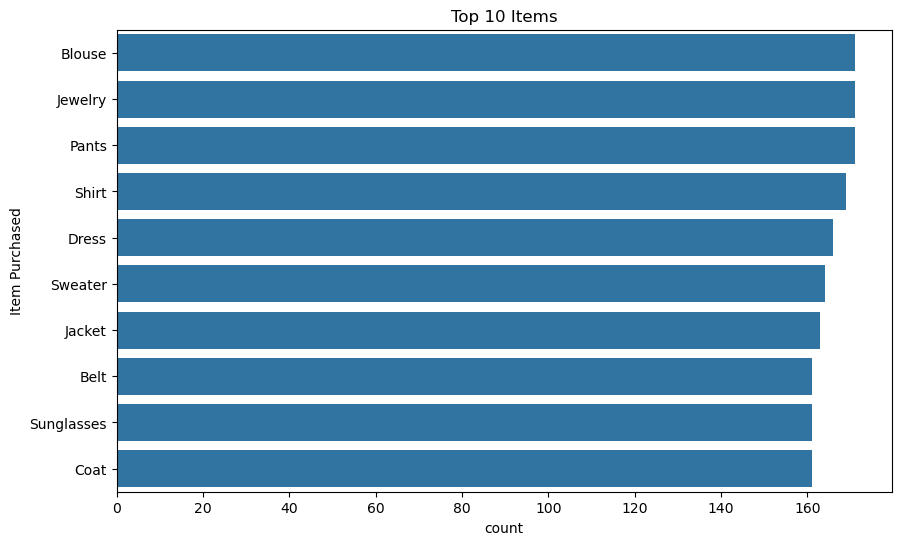

In [36]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=all_top.head(10),
    legend=True,
    x='count',
    y='Item Purchased'
)
plt.title('Top 10 Items')
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

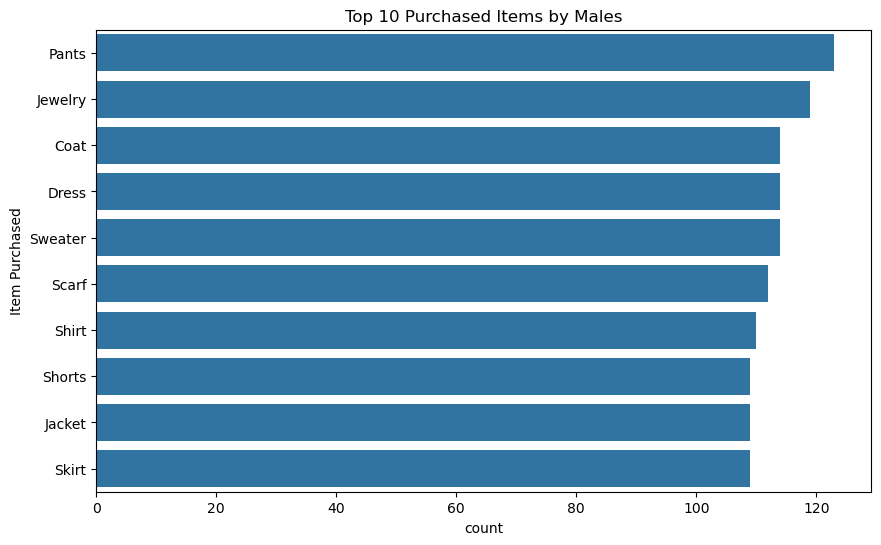

In [38]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=male_top.head(10),
    legend=True,
    x='count',
    y='Item Purchased'
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

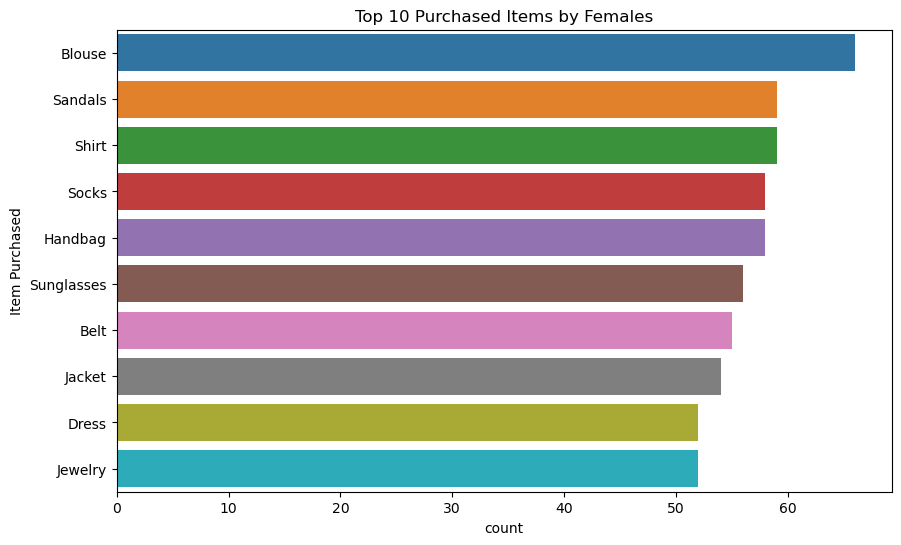

In [41]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=female_top.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [42]:
# TODO: count Size with value_counts() for all customers
all_customer_size = df['Size'].value_counts().reset_index()
all_customer_size

,Size,count
0,M,1755
1,L,1053
2,S,663
3,XL,429


In [46]:
# TODO: count Size with value_counts() for male_df and female_df
male_df_size = male_df['Size'].value_counts().reset_index()
female_df_size = female_df['Size'].value_counts().reset_index()
male_df_size

,Size,count
0,M,1165
1,L,716
2,S,476
3,XL,295


### **Category**

In [47]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [48]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
male_df_ctg = male_df['Category'].value_counts().reset_index()
female_df_ctg = female_df['Category'].value_counts().reset_index()
male_df_ctg

,Category,count
0,Clothing,1181
1,Accessories,848
2,Footwear,400
3,Outerwear,223


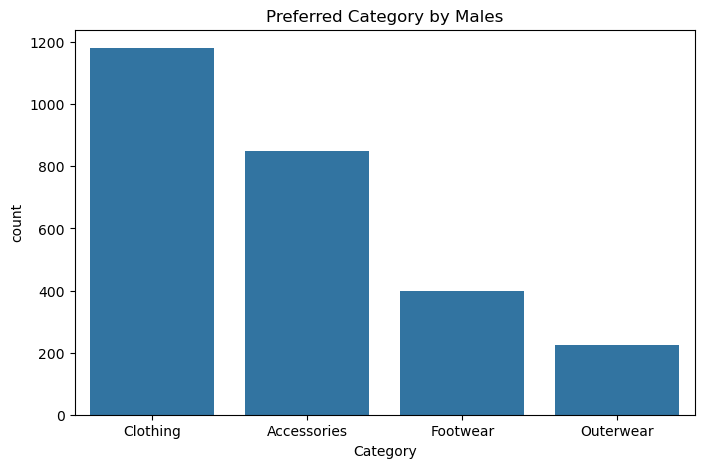

In [49]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Category',
    y='count',
    data=male_df_ctg
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

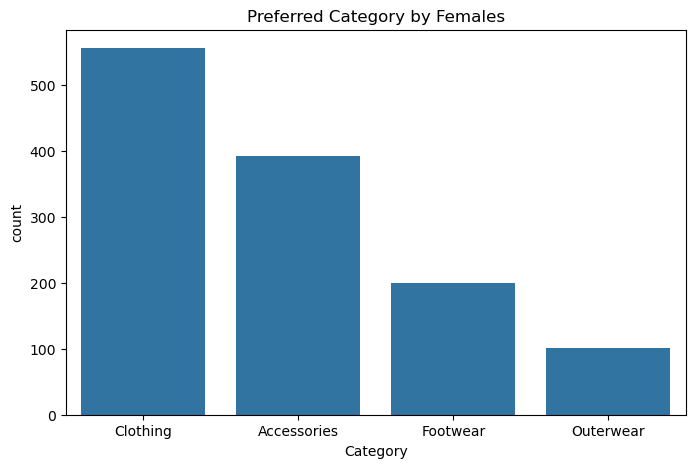

In [50]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Category',
    y='count',
    data=female_df_ctg
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

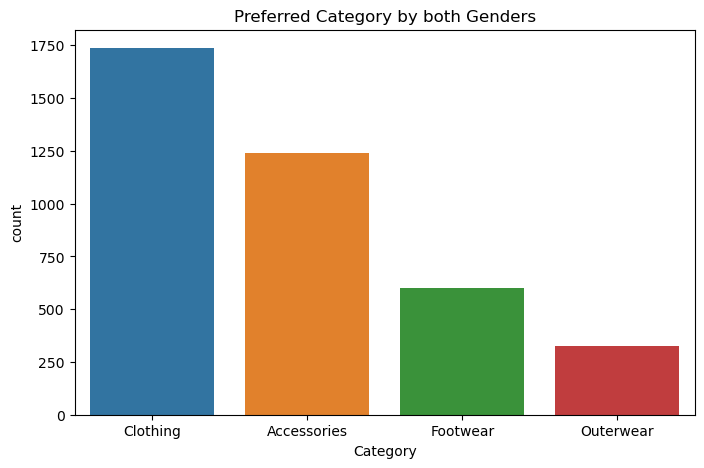

In [51]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()

In [52]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())

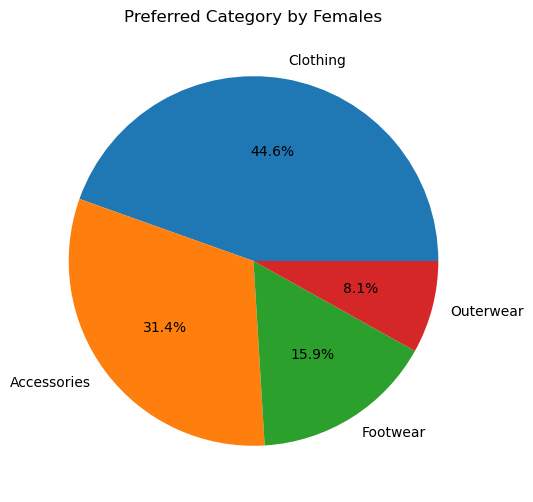

In [54]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    x=waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%',
)
plt.title("Preferred Category by Females")
plt.show()

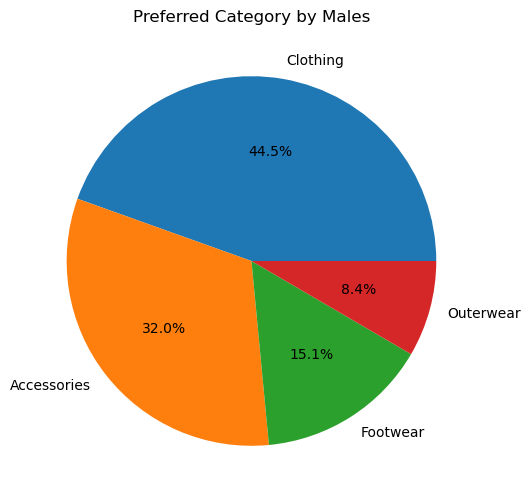

In [55]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [56]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']['Review Rating']
avg_cr_f = cr_f.mean()

In [57]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']['Review Rating']
avg_cr_m = cr_m.mean()

In [60]:
avg_cr_m,avg_cr_f

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

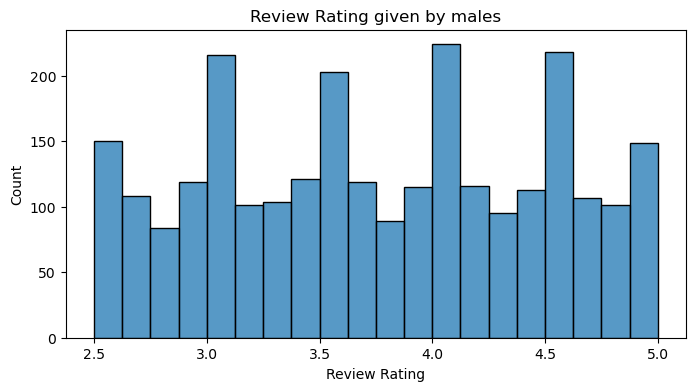

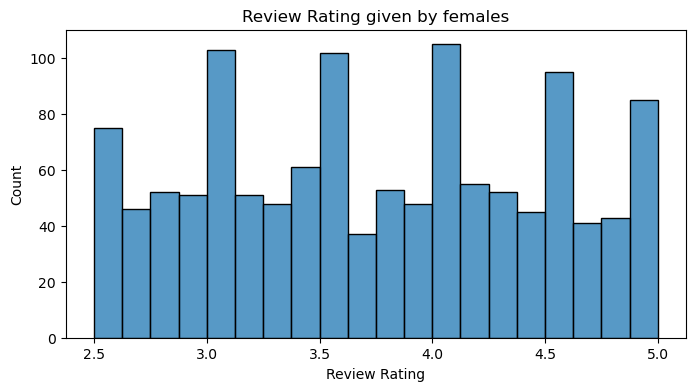

In [61]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [63]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m_counts = cr_m.value_counts().reset_index()
cr_m_counts

,Review Rating,count
0,3.7,61
1,3.4,59
2,2.9,55
3,2.7,55
4,4.0,52
5,3.9,52
6,4.2,52
7,3.0,49
8,3.3,49
9,4.1,48


### **Purchase Amount (USD)**

In [64]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()
m_tpa, f_tpa

(np.int64(157890), np.int64(75191))

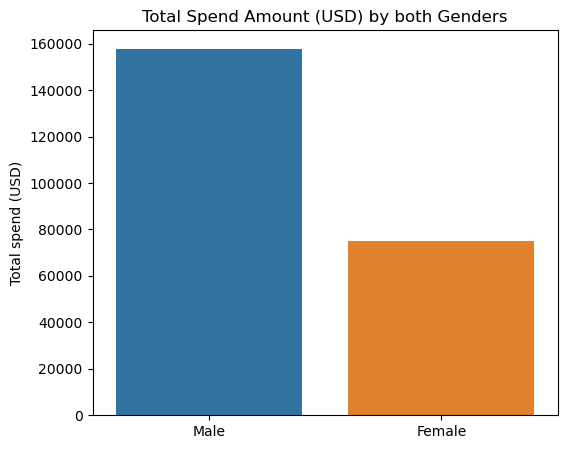

In [67]:
# TODO: plot total spend by gender with sns.barplot()
plt.figure(figsize=(6, 5))
sns.barplot(
    x=['Male', 'Female'],
    y=[m_tpa, f_tpa],
    hue=['Male', 'Female'],
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [68]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category']=='Footwear']
co_f = female_df[female_df['Category']=='Outerwear']

In [69]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category']=='Accessories']
cf_m = male_df[male_df['Category']=='Footwear']
co_m = male_df[male_df['Category']=='Outerwear']

In [71]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = cr_m.value_counts().to_dict()
pcu

{3.7: 61,
 3.4: 59,
 2.9: 55,
 2.7: 55,
 4.0: 52,
 3.9: 52,
 4.2: 52,
 3.0: 49,
 3.3: 49,
 4.1: 48,
 3.5: 48,
 4.9: 48,
 4.6: 46,
 4.7: 46,
 3.6: 46,
 4.8: 46,
 3.1: 46,
 2.6: 45,
 4.3: 45,
 4.4: 43,
 2.8: 41,
 3.2: 41,
 3.8: 39,
 4.5: 36,
 2.5: 17,
 5.0: 16}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

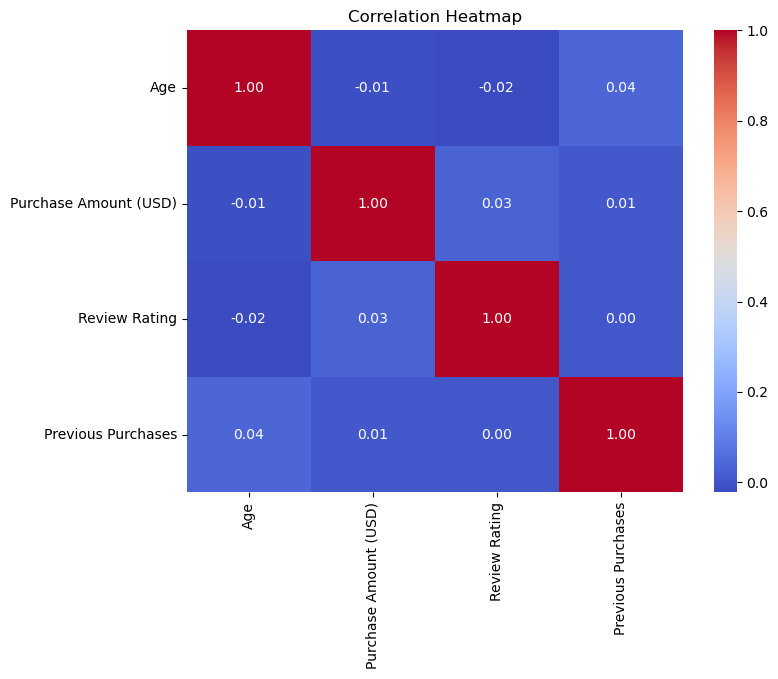

In [72]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [73]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [74]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [75]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)
df['Amount_bin'].value_counts()

Amount_bin
High      1447
Medium    1393
Low       1060
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Clothing là danh mục phổ biến nhất ở cả hai giới. Nam có 1.181 lượt mua Clothing, trong khi nữ có 556 lượt mua. Accessories là danh mục phổ biến thứ hai ở cả hai nhóm.
- Nam có tổng số tiền mua hàng cao hơn nữ, với nam chi 157.890 USD, trong khi nữ chi 75.191 USD. Tuy nhiên, sự khác biệt này cũng liên quan đến việc số lượng khách hàng nam trong dữ liệu nhiều hơn.
- Review Rating tương đối giống nhau giữa nam và nữ. Điểm đánh giá trung bình của nam khoảng 3,73, còn nữ khoảng 3,70, cho thấy sự khác biệt trong xu hướng đánh giá là không đáng kể.
- Các biến số có mối tương quan rất yếu với nhau. Hệ số tương quan lớn nhất là giữa Age và Previous Purchases với 0,04, trong khi Purchase Amount (USD) và Review Rating chỉ có tương quan 0,03. Điều này cho thấy không có mối quan hệ tuyến tính mạnh giữa các biến số trong dữ liệu.

Caveat: correlation is not causation.